In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

filepath = r"C:\Users\julia\downloads\IDX_summer_internship"
pattern = os.path.join(filepath, "CRMLSSold*.csv")
files = sorted(glob.glob(pattern))

# load and concatenate all files at once
df_list = [pd.read_csv(f, low_memory=False) for f in files]
data = pd.concat(df_list, ignore_index=True)

print(f"Loaded {len(files)} files")
print(f"Total rows: {len(data)}")
print(f"Columns: {data.shape[1]}")

Loaded 30 files
Total rows: 794271
Columns: 82


In [6]:
#applying data filter

filtered_data = data[(data['PropertyType'] == 'Residential') & (data['PropertySubType'] == 'SingleFamilyResidence')].copy()
print(filtered_data.shape)

(399157, 82)


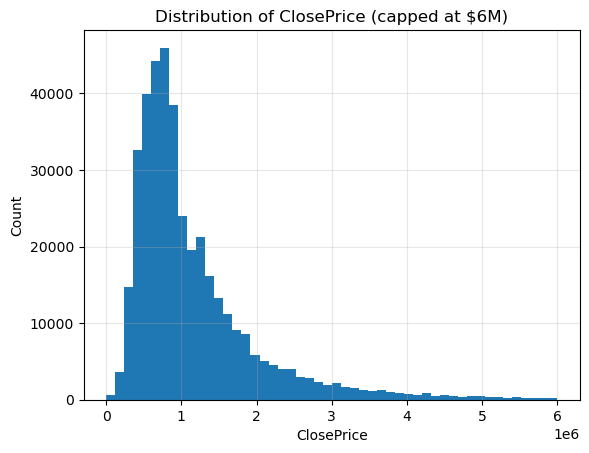

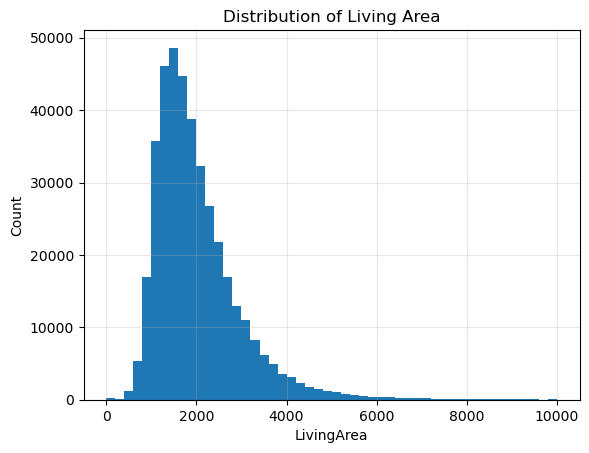

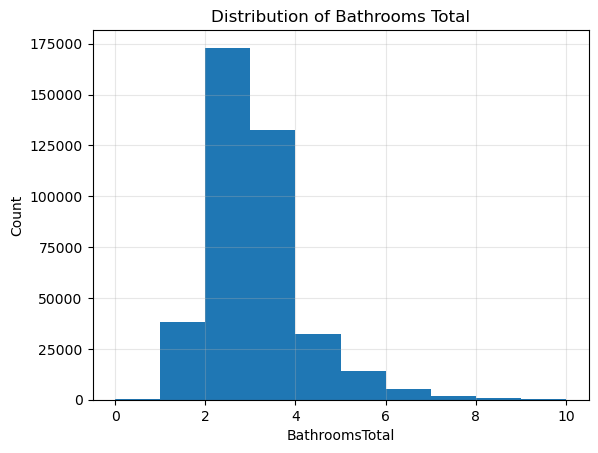

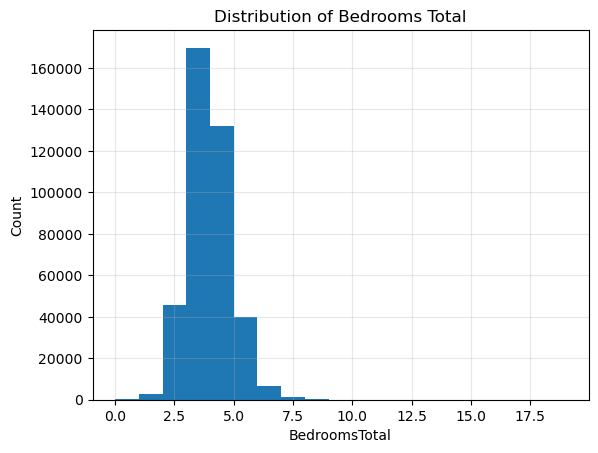

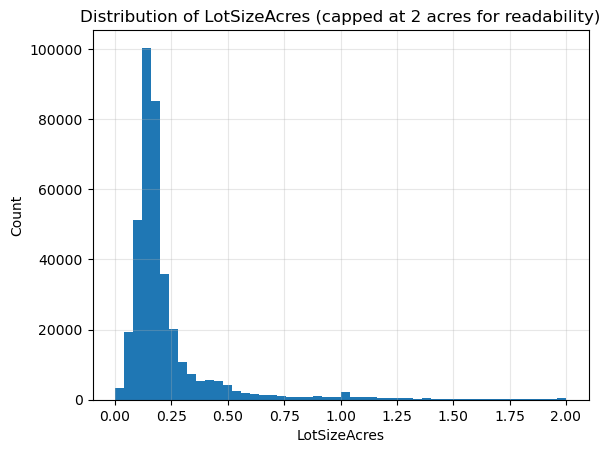

In [15]:
#histograms of data

# close price
filtered_data['ClosePrice'].hist(bins=50, range=(0, 6_000_000)) #capped price to make visualizaton better - some houses are way above average
plt.xlabel('ClosePrice')
plt.ylabel('Count')
plt.title('Distribution of ClosePrice (capped at $6M)')
plt.grid(alpha = 0.3)
plt.show()
plt.close()

# living area
filtered_data['LivingArea'].hist(bins=50, range=(0, 10000))
plt.xlabel('LivingArea')
plt.ylabel('Count')
plt.title('Distribution of Living Area')
plt.grid(alpha = 0.3)
plt.show()
plt.close()

# total bathrooms
filtered_data['BathroomsTotalInteger'].hist(range = (0, 10))
plt.xlabel('BathroomsTotal')
plt.ylabel('Count')
plt.title('Distribution of Bathrooms Total')
plt.grid(alpha = 0.3)
plt.show()
plt.close()

# total bedrooms
filtered_data['BedroomsTotal'].hist(bins=range(0, 20))
plt.xlabel('BedroomsTotal')
plt.ylabel('Count')
plt.title('Distribution of Bedrooms Total')
plt.grid(alpha = 0.3)
plt.show()
plt.close()

# lot size
filtered_data['LotSizeAcres'].hist(bins=50, range=(0, 2))
plt.xlabel('LotSizeAcres')
plt.ylabel('Count')
plt.title('Distribution of LotSizeAcres (capped at 2 acres for readability)')
plt.grid(alpha=0.3)
plt.show()
plt.close()

# Week 3: Data preprocessing, test/train split
The data ranges from January 2022 to May 2026. 

Previous to this step, we filter the data to single-family residential properties, because the end goal is to predict the closing price for this property type specifically. 

# Missing Value Handling
Below, we remove columns containing 100% missing values, as they will not provide useful information for modeling.

Additionally, we remove variables where there is more than 50% missing data, as imputing would introduce more synthetic values than real ones. For columns that remain, the data is imputed with the median value of the column where the column is numeric. The remaining categorial columns are imputed with the mode of the column.

# Data Type Conversion
Any date-related columns to datetime format to support time-based test/train splitting. Integer-like features (bedrooms, bathrooms, year built, stories, garage spaces, parking) are converted to integer format. PostalCode is converted to a string type as it represents a geographic label and is not truly a numeric quantity. GarageSpaces and ParkingTotal are converted from a float to an integer by rounding. Boolean columns are converted to binary integer representation (0/1). Finally, we drop coluns with only one unique value, as they are useless for modeling.

# Encoding
Below, one-hot encoding is applied to categorical columns with fewer than 15 unique values, which creates binary indicator columns for each category. Columns with more than 15 unique values (such as listing agent, etc.) are dropped due to their large number of unique values.

# Normalization
In this internship, we will later use linear regression, so normalization and scaling of the data is necessary because linear regression and other ML methods like GMM and Support Vectors are sensitive to feature scales. To perform normalization, continuous features were standardized using StandardScaler, which transforms each variable to have a mean of zero and have a standard deviation of one. This method ensures that features on different scales contribute equally to the model rather than allowing large-magnitude features to dominate.

# Test/Train split
Rather than splitting the data randomly, the most recent month of available data was reserved as the test set, which all earlier observations are used for training. 

In [10]:
# remove columns with 100 % missing data
data_clean = filtered_data.dropna(axis=1, how="all")
print(f"Columns remaining after 100% drop: {data_clean.shape[1]}")

Columns remaining after 100% drop: 74


In [14]:
# removing columns with more than 50% missing
threshold = 0.5
data_clean = data_clean.loc[:, data_clean.isnull().mean() < threshold]
print(f"Columns remaining after 50% drop: {data_clean.shape[1]}")

Columns remaining after 50% drop: 55
True


In [16]:
# imputing remaining missing values
for col in data_clean.columns:
    if data_clean[col].dtype in ['float64', 'int64']:
        # where numeric -> impute with median
        data_clean[col].fillna(data_clean[col].median(), inplace=True)
    else:
        # where categorical impute with mode
        data_clean[col].fillna(data_clean[col].mode()[0], inplace=True)


C:\Users\julia\AppData\Local\Temp\ipykernel_12496\3311598858.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_clean[col].fillna(data_clean[col].mode()[0], inplace=True)
C:\Users\julia\AppData\Local\Temp\ipykernel_12496\3311598858.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_clean[col].fillna

True


In [18]:
# converting date columns to datetime
date_cols = ['CloseDate', 'ListingContractDate', 
             'ContractStatusChangeDate', 'PurchaseContractDate']
for col in date_cols:
    if col in data_clean.columns:
        data_clean[col] = pd.to_datetime(data_clean[col], errors='coerce')

True


In [20]:
# converting integer-like features to integer format
int_cols = ['BedroomsTotal', 'BathroomsTotalInteger', 'YearBuilt', 
            'Stories', 'MainLevelBedrooms', 'GarageSpaces', 'ParkingTotal']

for col in int_cols:
    if col in data_clean.columns:
        data_clean[col] = pd.to_numeric(data_clean[col], errors='coerce').round().astype('Int64')

print(data_clean[int_cols].dtypes)

BedroomsTotal            Int64
BathroomsTotalInteger    Int64
YearBuilt                Int64
Stories                  Int64
MainLevelBedrooms        Int64
GarageSpaces             Int64
ParkingTotal             Int64
dtype: object
True


In [22]:
# converting PostalCode from numeric to a string variable
data_clean['PostalCode'] = data_clean['PostalCode'].astype(str)

print(data_clean['PostalCode'].dtype)
print(data_clean['PostalCode'].head())

object
3     92008
6     92352
7     92336
12    92234
14    95969
Name: PostalCode, dtype: object
True


In [24]:
# Converting GarageSpaces and ParkingTotal to handle conversion

data_clean['GarageSpaces'] = pd.to_numeric(data_clean['GarageSpaces'], errors='coerce').round().astype('Int64')
data_clean['ParkingTotal'] = pd.to_numeric(data_clean['ParkingTotal'], errors='coerce').round().astype('Int64')

print(data_clean['GarageSpaces'].value_counts().head())
print(data_clean['ParkingTotal'].value_counts().head())

GarageSpaces
2    265246
3     58936
1     33389
0     32072
4      6628
Name: count, dtype: Int64
ParkingTotal
2    214096
3     51586
4     42480
1     26186
0     23072
Name: count, dtype: Int64
True


In [26]:
# Converting Boolean to binary
bool_cols = ['ViewYN', 'PoolPrivateYN', 'AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN']

for col in bool_cols:
    if col in data_clean.columns:
        data_clean[col] = data_clean[col].astype(int)

print(data_clean[bool_cols].dtypes)

ViewYN               int32
PoolPrivateYN        int32
AttachedGarageYN     int32
FireplaceYN          int32
NewConstructionYN    int32
dtype: object
True


In [28]:
# drop columns with only 1 unique value, dropping columns with non-useful object columns
single_value_cols = [col for col in data_clean.columns 
                     if data_clean[col].nunique() == 1]
print(f"Dropping single value columns: {single_value_cols}")
data_clean = data_clean.drop(columns=single_value_cols)

# drop high cardinality and non-useful object columns
drop_cols = [
    'ListAgentEmail', 'ListAgentFirstName', 'ListAgentLastName',
    'ListAgentFullName', 'ListOfficeName', 'BuyerOfficeName',
    'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
    'UnparsedAddress', 'ListingId', 'Flooring', 'MLSAreaMajor', 
    'ContractStatusChangeDate', 'PurchaseContractDate', 
    'ListingContractDate'
]
drop_cols = [c for c in drop_cols if c in data_clean.columns]
data_clean = data_clean.drop(columns=drop_cols)
print(f"Shape after dropping: {data_clean.shape}")

Dropping single value columns: ['PropertyType', 'MlsStatus', 'PropertySubType']
Shape after dropping: (399157, 36)


In [30]:
# one-hot encoding 

ohe_cols = [col for col in data_clean.select_dtypes(include='object').columns
            if data_clean[col].nunique() < 100]

print(f"Encoding: {ohe_cols}")
print(f"Skipping (too many categories): {[col for col in data_clean.select_dtypes(include='object').columns if col not in ohe_cols]}")

data_clean = pd.get_dummies(data_clean, columns=ohe_cols, drop_first=True)
print(f"Shape after encoding: {data_clean.shape}")

Encoding: ['CountyOrParish', 'BuyerOfficeAOR', 'StateOrProvince', 'Levels', 'BuyerAgentAOR', 'ListAgentAOR']
Skipping (too many categories): ['City', 'HighSchoolDistrict', 'PostalCode']
Shape after encoding: (399157, 317)


In [32]:
# Normalization
from sklearn.preprocessing import StandardScaler

continuous_columns = [
    "Latitude", "Longitude", "LivingArea", "DaysOnMarket",
    "ParkingTotal", "LotSizeAcres", "YearBuilt", "StreetNumberNumeric",
    "BathroomsTotalInteger", "BedroomsTotal", "Stories", "LotSizeArea",
    "MainLevelBedrooms", "GarageSpaces", "AssociationFee", "LotSizeSquareFeet"
]

scaler = StandardScaler()
data_clean[continuous_columns] = scaler.fit_transform(data_clean[continuous_columns])
print(f"Scaled {len(continuous_columns)} continuous features.")

Scaled 16 continuous features.


In [34]:
# test/train split

data_clean["CloseDate"] = pd.to_datetime(data_clean["CloseDate"], format="mixed")

latest_month = data_clean["CloseDate"].dt.to_period("M").max()

train_df = data_clean[data_clean["CloseDate"].dt.to_period("M") < latest_month].copy()
test_df = data_clean[data_clean["CloseDate"].dt.to_period("M") == latest_month].copy()

print(f"Training rows: {len(train_df):,}")
print(f"Testing rows:  {len(test_df):,}")

Training rows: 387,133
Testing rows:  12,024


In [36]:
# exporting cleaned CSV's
data_clean.to_csv(filepath + r"\train_cleaned.csv", index=False)
test_df.to_csv(filepath + r"\test_cleaned.csv", index=False)
print("Saved train_cleaned.csv and test_cleaned.csv")

Saved train_cleaned.csv and test_cleaned.csv
